# OHCA AED Accessibility Analysis with 2SFCA (Google Colab)

This notebook simulates **200 AED locations in Georgia** and evaluates accessibility for OHCA events using the **Two-Step Floating Catchment Area (2SFCA)** method.

## Workflow
1. Load OHCA points.
2. Load county boundaries and keep Georgia counties only.
3. Simulate 200 random AED points inside Georgia.
4. Compute AED supply ratios (Step 1 of 2SFCA).
5. Compute OHCA accessibility scores (Step 2 of 2SFCA).
6. Summarize and map county-level accessibility, then export outputs.

## 1. Install Packages

In [1]:
# Install required geospatial libraries for this analysis.
!pip -q install geopandas shapely matplotlib contextily

In [8]:
# Mount Google Drive so notebook data files are accessible.
from google.colab import drive
# Mount Google Drive so the notebook can read and write workshop files.
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [12]:
# Import os package for file path and file system operations
# List all files in COLAB_DATA_DIR = Path('/content/drive/MyDrive/Colab Notebooks/Using-Python-for-Geospatial-Analysis-and-Visualization-main/data')
import os
from pathlib import Path
# Set the folder path where the workshop data files are stored.
COLAB_DATA_DIR = Path('/content/drive/MyDrive/Colab Notebooks/Using-Python-for-Geospatial-Analysis-and-Visualization-main/data')
for root, dirs, files in os.walk(COLAB_DATA_DIR):
    for file in files:
        print(Path(root) / file)

/content/drive/MyDrive/Colab Notebooks/Using-Python-for-Geospatial-Analysis-and-Visualization-main/data/svi_variables_code.pdf
/content/drive/MyDrive/Colab Notebooks/Using-Python-for-Geospatial-Analysis-and-Visualization-main/data/ohca_connected_data.csv
/content/drive/MyDrive/Colab Notebooks/Using-Python-for-Geospatial-Analysis-and-Visualization-main/data/svi_GA_county.csv
/content/drive/MyDrive/Colab Notebooks/Using-Python-for-Geospatial-Analysis-and-Visualization-main/data/cb_2018_us_zcta510_500k/cb_2018_us_zcta510_500k.shp.ea.iso - Copy.xml
/content/drive/MyDrive/Colab Notebooks/Using-Python-for-Geospatial-Analysis-and-Visualization-main/data/cb_2018_us_zcta510_500k/cb_2018_us_zcta510_500k - Copy.prj
/content/drive/MyDrive/Colab Notebooks/Using-Python-for-Geospatial-Analysis-and-Visualization-main/data/cb_2018_us_zcta510_500k/cb_2018_us_zcta510_500k - Copy.dbf
/content/drive/MyDrive/Colab Notebooks/Using-Python-for-Geospatial-Analysis-and-Visualization-main/data/cb_2018_us_zcta510_

## 2. Imports and Paths

In [13]:
# Import Path so file and folder paths can be built with the / operator.
from pathlib import Path
# Import NumPy and give it the short name np for numerical calculations.
import numpy as np
# Import pandas and give it the short name pd for working with tabular data.
import pandas as pd
# Import GeoPandas and give it the short name gpd for working with spatial data.
import geopandas as gpd
# Import pyplot and give it the short name plt for creating plots.
import matplotlib.pyplot as plt

# Import Point so individual point geometries can be created later.
from shapely.geometry import Point

# Store the local data folder path for running the notebook on this computer.
LOCAL_DATA_DIR = Path('/Users/jenny/Desktop/Using-Python-for-Geospatial-Analysis-and-Visualization-main/data')
# Store the Google Colab data folder path for running the notebook in Colab.
COLAB_DATA_DIR = Path('/content/drive/MyDrive/Colab Notebooks/Using-Python-for-Geospatial-Analysis-and-Visualization-main/data')

# Use the Colab data folder if it exists; otherwise use the local data folder.
DATA_DIR = COLAB_DATA_DIR if COLAB_DATA_DIR.exists() else LOCAL_DATA_DIR

# Build the full path to the OHCA connected data CSV file.
OHCA_CSV = DATA_DIR/'ohca_connected_data.csv'
# Build the full path to the county shapefile.
COUNTY_SHP = DATA_DIR/'cb_2018_us_county_500k'/'cb_2018_us_county_500k - Copy.shp'

# Print the OHCA CSV path so you can confirm which file will be loaded.
print('OHCA file:', OHCA_CSV)

# Print the county shapefile path so you can confirm which file will be loaded.
print('County shapefile:', COUNTY_SHP)

OHCA file: /content/drive/MyDrive/Colab Notebooks/Using-Python-for-Geospatial-Analysis-and-Visualization-main/data/ohca_connected_data.csv
County shapefile: /content/drive/MyDrive/Colab Notebooks/Using-Python-for-Geospatial-Analysis-and-Visualization-main/data/cb_2018_us_county_500k/cb_2018_us_county_500k - Copy.shp


## 3. Load OHCA Points

In [14]:
# Define OHCA coordinate column names used to build point geometries.
lat_col = 'scene_gps_latitude_escene.11'
# Name the coordinate column used to locate OHCA events.
lon_col = 'scene_gps_longitude_escene.11'

# Read the CSV data into a pandas DataFrame.
ohca = pd.read_csv(OHCA_CSV)
# Convert this column to numeric values and mark invalid entries as missing.
ohca[lat_col] = pd.to_numeric(ohca[lat_col], errors='coerce')
# Convert this column to numeric values and mark invalid entries as missing.
ohca[lon_col] = pd.to_numeric(ohca[lon_col], errors='coerce')
# Drop records with missing values required for this analysis.
ohca = ohca.dropna(subset=[lat_col, lon_col]).copy()

# Convert dataframe to Geospatial Dataframe.
ohca_points = gpd.GeoDataFrame(
    ohca,
    geometry=gpd.points_from_xy(ohca[lon_col], ohca[lat_col]),
    crs='EPSG:4326'
)

# Print this value to check the analysis result.
print('OHCA points:', len(ohca_points))

OHCA points: 6005


## 4. Load Georgia Counties and Keep Georgia OHCA

In [15]:
# Load Georgia county boundaries and align them to WGS84 coordinates.
county = gpd.read_file(COUNTY_SHP).to_crs('EPSG:4326')
# Filter the county layer to Georgia and keep only identifier and geometry fields.
ga_counties = county[county['STATEFP'].astype(str) == '13'][['GEOID', 'NAME', 'geometry']].copy()

# Spatial Join OHCA points to Georgia counties.
ohca_ga = gpd.sjoin(
    ohca_points,
    ga_counties,
    how='inner',
    predicate='within'
).drop(columns=['index_right'], errors='ignore')

# Print this value to check the analysis result.
print('Georgia counties:', len(ga_counties))
# Print this value to check the analysis result.
print('OHCA points within Georgia counties:', len(ohca_ga))

Georgia counties: 159
OHCA points within Georgia counties: 5963


## 5. Simulate 200 AED Points in Georgia

This uses uniform random sampling inside the Georgia polygon extent and retains only points that fall within Georgia.

In [16]:
# Seed the random generator so synthetic AED placement is reproducible.
rng = np.random.default_rng(42)

# Set the number of synthetic AED locations to generate.
target_n = 200

# Combine all Georgia county polygons into one statewide boundary.
ga_polygon = ga_counties.unary_union

# Get the rectangular bounding box around Georgia for random point generation.
minx, miny, maxx, maxy = ga_polygon.bounds

# Store synthetic AED point geometries that fall inside Georgia.
aed_points = []

# Keep generating candidate coordinates until the target number of AED points is reached.
while len(aed_points) < target_n:
    # Generate batches of random x/y coordinates within Georgia's bounding box.
    xs = rng.uniform(minx, maxx, size=1000)
    # Generate random candidate coordinates within the study area bounds.
    ys = rng.uniform(miny, maxy, size=1000)

    # Convert each candidate coordinate pair into a point and test if it is inside Georgia.
    for x, y in zip(xs, ys):
        # Create a point geometry from the candidate x/y coordinate pair.
        p = Point(x, y)
        # Check whether this condition is true before continuing.
        if ga_polygon.covers(p):
            # Keep only points located within the Georgia boundary.
            aed_points.append(p)
            # Check whether this condition is true before continuing.
            if len(aed_points) >= target_n:
                # Stop once enough AED points have been generated.
                break

# Build a GeoDataFrame with synthetic AED IDs and point geometries.
aed_gdf = gpd.GeoDataFrame(
    {'aed_id': [f'AED_{i+1:03d}' for i in range(target_n)]},
    geometry=aed_points,
    crs='EPSG:4326'
)

# Confirm how many synthetic AED points were created and preview the first rows.
print('Simulated AED points:', len(aed_gdf))
# Preview the first rows of the result.
aed_gdf.head()

/tmp/ipykernel_7903/3525287847.py:8: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  ga_polygon = ga_counties.unary_union


Simulated AED points: 200


,aed_id,geometry
0,AED_001,POINT (-83.51372 32.48547)
1,AED_002,POINT (-81.51357 30.95691)
2,AED_003,POINT (-82.2819 31.06507)
3,AED_004,POINT (-85.15637 33.29342)
4,AED_005,POINT (-81.85923 31.83963)


## 6. Map Georgia Counties, OHCA, and Simulated AEDs

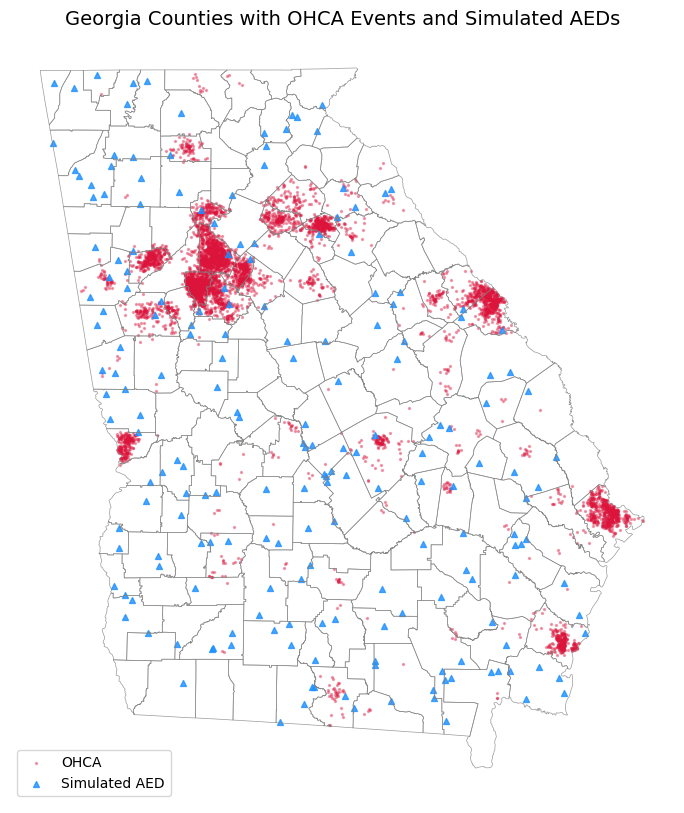

In [17]:
# Create a 10-by-10 inch plotting area for the OHCA and AED map.
fig, ax = plt.subplots(figsize=(10, 10))
# Draw Georgia county boundaries as gray outline polygons.
ga_counties.boundary.plot(ax=ax, linewidth=0.5, color='gray', alpha=0.8)
# Plot OHCA event points as small semi-transparent crimson dots.
ohca_ga.plot(ax=ax, markersize=2, color='crimson', alpha=0.35, label='OHCA')
# Plot simulated AED locations as larger semi-transparent blue triangles.
aed_gdf.plot(ax=ax, markersize=18, color='dodgerblue', alpha=0.8, marker='^', label='Simulated AED')
# Add a title to describe the map.
ax.set_title('Georgia Counties with OHCA Events and Simulated AEDs', fontsize=14)
# Add a legend in the lower-left corner to label the OHCA and AED symbols.
ax.legend(loc='lower left')
# Hide the x- and y-axis lines and labels.
ax.axis('off')
# Display the finished OHCA and AED map.
plt.show()

## 7. 2SFCA Step 1 and Step 2

- **Step 1:** For each AED location *j*, calculate supply ratio: `Rj = Sj / sum(Dk within catchment of j)`
- **Step 2:** For each OHCA event *i*, calculate accessibility score: `Ai = sum(Rj for AEDs within catchment of i)`

In this instructional example:
- AED supply `Sj = 1` for each AED
- OHCA demand `Dk = 1` for each OHCA event
- Catchment is a fixed distance threshold in miles

In [18]:
# Reproject OHCA points to EPSG:3857 so distances are measured in meters.
ohca_ga_3857 = ohca_ga.to_crs('EPSG:3857').copy()
# Reproject simulated AED points to EPSG:3857 so they use the same meter-based coordinate system.
aed_3857 = aed_gdf.to_crs('EPSG:3857').copy()

# Build a two-column array of OHCA x and y coordinates in meters.
ohca_xy = np.column_stack([ohca_ga_3857.geometry.x.values, ohca_ga_3857.geometry.y.values])
# Build a two-column array of AED x and y coordinates in meters.
aed_xy = np.column_stack([aed_3857.geometry.x.values, aed_3857.geometry.y.values])

# Subtract every AED x-coordinate from every OHCA x-coordinate.
dx = ohca_xy[:, None, 0] - aed_xy[None, :, 0]
# Subtract every AED y-coordinate from every OHCA y-coordinate.
dy = ohca_xy[:, None, 1] - aed_xy[None, :, 1]
# Use the x and y differences to calculate the straight-line distance from each OHCA point to each AED.
dist_m = np.sqrt(dx**2 + dy**2)

# Set the 2SFCA catchment distance to 5 miles.
catchment_miles = 5
# Convert the 5-mile catchment distance to meters.
catchment_m = catchment_miles * 1609.344

# Print the number of OHCA point coordinate rows.
print('OHCA points:', ohca_xy.shape[0])
# Print the number of AED point coordinate rows.
print('AED points:', aed_xy.shape[0])
# Print the size of the OHCA-by-AED distance matrix.
print('Distance matrix shape:', dist_m.shape)
# Print the catchment distance in miles.
print('Catchment threshold (miles):', catchment_miles)

OHCA points: 5963
AED points: 200
Distance matrix shape: (5963, 200)
Catchment threshold (miles): 5


## 8. 2SFCA Step 1: AED Supply Ratios (Rj)

For each AED `j`, calculate:

`Rj = Sj / sum(Dk)` for OHCA demand points `k` within the AED catchment.

Here, `Sj = 1` AED and each OHCA event has `Dk = 1` demand unit.

In [19]:
# Mark each OHCA-AED pair as True when its distance is within the catchment threshold.
within_catchment = dist_m <= catchment_m

# Count how many OHCA points fall within the catchment area of each AED.
demand_per_aed = within_catchment.sum(axis=0).astype(float)

# Create one supply value for each AED, with each AED counted as one unit of supply.
supply_per_aed = np.ones_like(demand_per_aed)  # one AED unit per AED point


In [20]:
# Display the supply value assigned to each AED.
supply_per_aed

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [21]:
# Display the number of OHCA points within each AED catchment.
demand_per_aed

array([  0.,   0.,   0.,   0.,   0.,   1.,   0.,   3.,   0.,   0.,   0.,
         0.,   0.,   0.,   1.,   0.,   0.,  11.,  17.,   0.,   0.,   0.,
         0.,  33.,   0.,   0.,   0.,   0.,   0.,  18.,  55.,   0.,   0.,
        23.,   0.,  23.,   1.,   0.,   0.,   0.,   0.,   0.,  30.,   0.,
         0.,  18.,   0.,   0.,  71.,   0.,   8.,   0.,   0.,   0.,   0.,
         2.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,  76.,
        18.,   3.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,  71.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,   0.,  37.,
         1.,   0.,   0.,  16.,   4.,   0.,   0.,   1.,   1.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,  47.,   0.,   0.,   0.,   0.,   0.,   0., 132.,   0.,   8.,
         5.,   0.,   3.,   0.,   0.,   2.,   0.,   

In [22]:
# Divide each AED's supply value by its OHCA demand count, using 0 when an AED has no demand.
Rj = np.divide(
    supply_per_aed,
    demand_per_aed,
    out=np.zeros_like(demand_per_aed, dtype=float),
    where=demand_per_aed > 0
)


In [23]:
# Add each AED's OHCA catchment count as a new column.
aed_3857['demand_in_catchment'] = demand_per_aed
# Add each AED's supply-to-demand ratio as a new column.
aed_3857['Rj_supply_ratio'] = Rj

# Display summary statistics for AED catchment counts and supply-to-demand ratios.
aed_3857[['demand_in_catchment', 'Rj_supply_ratio']].describe()

,demand_in_catchment,Rj_supply_ratio
count,200.000000,200.000000
mean,4.020000,0.080069
std,14.759363,0.244351
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,132.000000,1.000000


## 9. 2SFCA Step 2: OHCA Accessibility Scores (Ai)

For each OHCA event `i`, calculate:

`Ai = sum(Rj)` for AEDs `j` within the event catchment.

Higher `Ai` indicates better AED accessibility under the selected catchment threshold.

In [24]:
# For each OHCA point, add up the Rj values for AEDs inside that point's catchment.
Ai = (within_catchment * Rj[None, :]).sum(axis=1)

# Add each OHCA point's 2SFCA accessibility score as a new column.
ohca_ga_3857['Ai_2sfca'] = Ai
# Add the number of AEDs within each OHCA point's catchment as a new column.
ohca_ga_3857['aed_count_within_catchment'] = within_catchment.sum(axis=1)
# Add a 1/0 flag showing whether each OHCA point has at least one AED in its catchment.
ohca_ga_3857['has_aed_in_catchment'] = (ohca_ga_3857['aed_count_within_catchment'] > 0).astype(int)

# Build a one-column summary of event-level 2SFCA results.
event_2sfca_summary = pd.Series({
    'events_total': len(ohca_ga_3857),
    'catchment_miles': catchment_miles,
    'mean_Ai_2sfca': ohca_ga_3857['Ai_2sfca'].mean(),
    'median_Ai_2sfca': ohca_ga_3857['Ai_2sfca'].median(),
    'pct_events_with_aed_in_catchment': ohca_ga_3857['has_aed_in_catchment'].mean() * 100,
    'max_Ai_2sfca': ohca_ga_3857['Ai_2sfca'].max()
})

# Group OHCA points by county and calculate county-level accessibility summary values.
county_access = (
    ohca_ga_3857.groupby(['GEOID', 'NAME'])
    .agg(
        ohca_events=('incident_date', 'count'),
        mean_Ai_2sfca=('Ai_2sfca', 'mean'),
        median_Ai_2sfca=('Ai_2sfca', 'median'),
        pct_events_with_aed_in_catchment=('has_aed_in_catchment', 'mean')
    )
    .reset_index()
)
# Convert the county AED-in-catchment rate from a proportion to a percentage.
county_access['pct_events_with_aed_in_catchment'] *= 100

# Print a heading for the event-level summary output.
print('Event-level 2SFCA summary:')
# Print the event-level 2SFCA summary values.
print(event_2sfca_summary)

# Display the 15 counties with the highest mean 2SFCA accessibility score.
county_access.sort_values('mean_Ai_2sfca', ascending=False).head(15)

Event-level 2SFCA summary:
events_total                        5963.000000
catchment_miles                        5.000000
mean_Ai_2sfca                          0.007043
median_Ai_2sfca                        0.000000
pct_events_with_aed_in_catchment      13.315445
max_Ai_2sfca                           1.333333
dtype: float64


,GEOID,NAME,ohca_events,mean_Ai_2sfca,median_Ai_2sfca,pct_events_with_aed_in_catchment
62,13191,McIntosh,1,1.000000,1.000000,100.000000
5,13023,Bleckley,3,0.444444,0.333333,66.666667
87,13285,Troup,6,0.333333,0.166667,50.000000
52,13159,Jasper,1,0.333333,0.333333,100.000000
84,13267,Tattnall,3,0.333333,0.000000,33.333333
32,13105,Elbert,8,0.250000,0.125000,50.000000
94,13305,Wayne,4,0.250000,0.000000,25.000000
37,13119,Franklin,1,0.125000,0.125000,100.000000
64,13195,Madison,19,0.105263,0.062500,52.631579
90,13297,Walton,13,0.076923,0.000000,7.692308


## 10. Map County Mean 2SFCA Accessibility Score (Ai)

/usr/local/lib/python3.12/dist-packages/mapclassify/classifiers.py:1767: UserWarning: Not enough unique values in array to form 5 classes. Setting k to 3.
  self.bins = quantile(y, k=k)


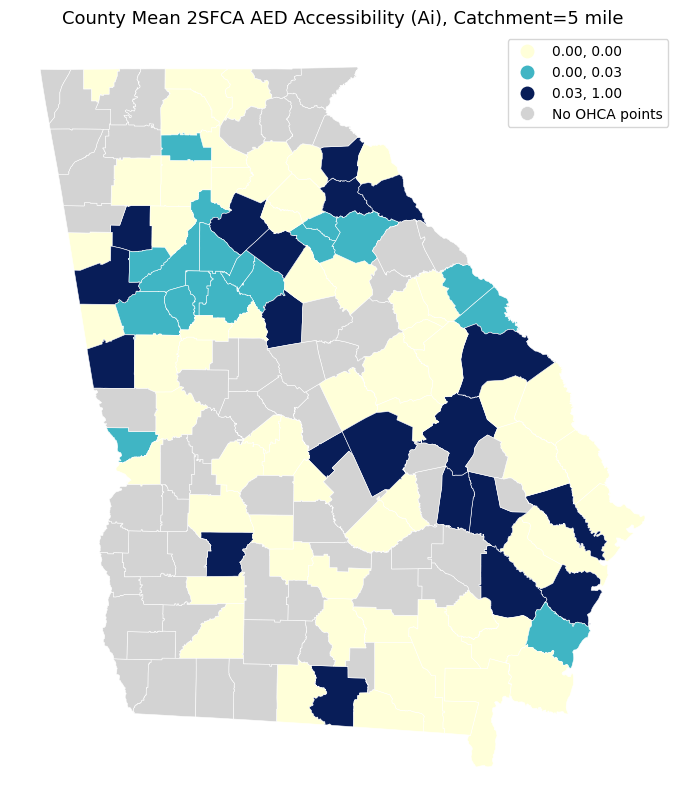

In [25]:
# Attach each county's accessibility summary values to its county polygon.
county_access_map = ga_counties.merge(county_access, on=['GEOID', 'NAME'], how='left')

# Create a 10-by-10 inch plotting area for the county accessibility map.
fig, ax = plt.subplots(figsize=(10, 10))
# Draw counties colored by mean 2SFCA accessibility score, grouped into 5 quantile classes.
county_access_map.plot(
    column='mean_Ai_2sfca',
    cmap='YlGnBu',
    scheme='quantiles',
    k=5,
    legend=True,
    linewidth=0.4,
    edgecolor='white',
    ax=ax,
    missing_kwds={'color': 'lightgray', 'label': 'No OHCA points'}
)
# Add a title that includes the catchment distance used in the accessibility calculation.
ax.set_title(f'County Mean 2SFCA AED Accessibility (Ai), Catchment={catchment_miles} mile', fontsize=13)
# Hide the x- and y-axis lines and labels.
ax.axis('off')
# Display the finished county accessibility map.
plt.show()

## 11. Export Outputs

/usr/local/lib/python3.12/dist-packages/mapclassify/classifiers.py:1767: UserWarning: Not enough unique values in array to form 5 classes. Setting k to 3.
  self.bins = quantile(y, k=k)


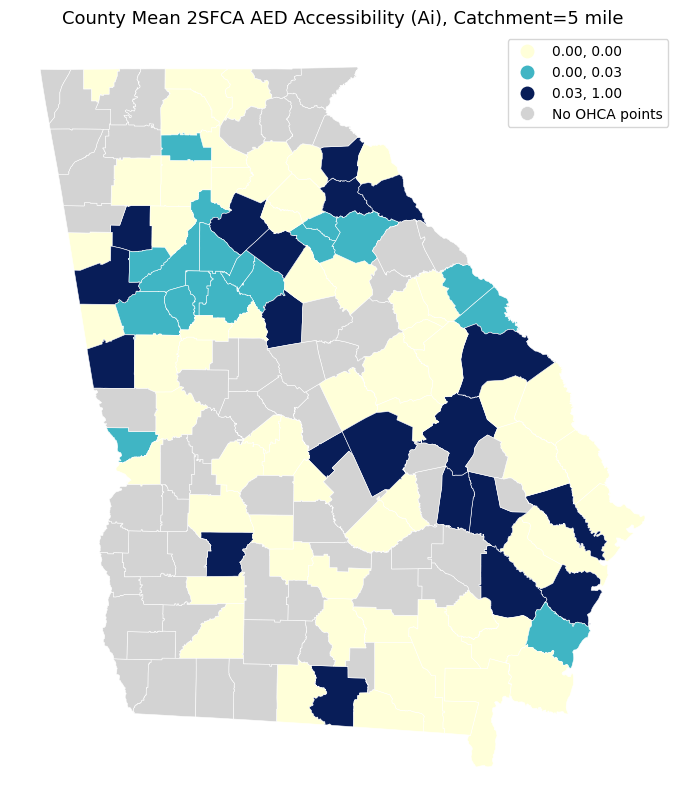

Saved AED points: /content/drive/MyDrive/Colab Notebooks/Using-Python-for-Geospatial-Analysis-and-Visualization-main/data/outputs/simulated_aed_points_200.geojson
Saved event-level 2SFCA accessibility: /content/drive/MyDrive/Colab Notebooks/Using-Python-for-Geospatial-Analysis-and-Visualization-main/data/outputs/ohca_event_2sfca_accessibility.csv
Saved county 2SFCA summary: /content/drive/MyDrive/Colab Notebooks/Using-Python-for-Geospatial-Analysis-and-Visualization-main/data/outputs/county_2sfca_aed_accessibility_summary.csv
Saved 2SFCA map PNG: /content/drive/MyDrive/Colab Notebooks/Using-Python-for-Geospatial-Analysis-and-Visualization-main/data/outputs/county_mean_2sfca_aed_accessibility_map.png


In [26]:
# Build the path to the outputs folder inside the selected data folder.
OUTPUT_DIR = DATA_DIR / 'outputs'
# Create the output folder if it does not already exist.
OUTPUT_DIR.mkdir(exist_ok=True)

# Build the output path for the simulated AED point GeoJSON file.
aed_geojson = OUTPUT_DIR / 'simulated_aed_points_200.geojson'
# Build the output path for the event-level 2SFCA accessibility CSV file.
event_csv = OUTPUT_DIR / 'ohca_event_2sfca_accessibility.csv'
# Build the output path for the county-level 2SFCA summary CSV file.
county_csv = OUTPUT_DIR / 'county_2sfca_aed_accessibility_summary.csv'
# Build the output path for the county accessibility map PNG file.
map_png = OUTPUT_DIR / 'county_mean_2sfca_aed_accessibility_map.png'

# Save the simulated AED points as a GeoJSON file.
aed_gdf.to_file(aed_geojson, driver='GeoJSON')
# Convert OHCA event results back to latitude-longitude, remove geometry, and save them as a CSV file.
ohca_ga_3857.to_crs('EPSG:4326').drop(columns='geometry').to_csv(event_csv, index=False)
# Save the county-level accessibility summary as a CSV file.
county_access.to_csv(county_csv, index=False)

# Create a 10-by-10 inch plotting area for the map image that will be saved.
fig, ax = plt.subplots(figsize=(10, 10))
# Draw counties colored by mean 2SFCA accessibility score, grouped into 5 quantile classes.
county_access_map.plot(
    column='mean_Ai_2sfca',
    cmap='YlGnBu',
    scheme='quantiles',
    k=5,
    legend=True,
    linewidth=0.4,
    edgecolor='white',
    ax=ax,
    missing_kwds={'color': 'lightgray', 'label': 'No OHCA points'}
)
# Add a title that includes the catchment distance used in the accessibility calculation.
ax.set_title(f'County Mean 2SFCA AED Accessibility (Ai), Catchment={catchment_miles} mile', fontsize=13)
# Hide the x- and y-axis lines and labels.
ax.axis('off')
# Save the county accessibility map as a 300-DPI PNG file.
fig.savefig(map_png, dpi=300, bbox_inches='tight')
# Display the saved county accessibility map.
plt.show()

# Print the file path where the AED GeoJSON was saved.
print('Saved AED points:', aed_geojson)
# Print the file path where the event-level accessibility CSV was saved.
print('Saved event-level 2SFCA accessibility:', event_csv)
# Print the file path where the county summary CSV was saved.
print('Saved county 2SFCA summary:', county_csv)
# Print the file path where the map PNG was saved.
print('Saved 2SFCA map PNG:', map_png)

## Notes

- This notebook uses **simulated AED locations** for instruction only.
- For real studies, replace simulated AEDs with validated AED inventory data.
- 2SFCA explicitly combines **supply** (AED availability) and **demand** (OHCA events) in local catchments.
- `Ai` is a relative accessibility score: higher values indicate better accessibility under the same catchment assumptions.
- Test sensitivity by changing `catchment_miles` (for example: 0.5, 1.0, 2.0 miles).